<a href="https://colab.research.google.com/github/laleejyo/tensors/blob/main/Transfer_learning_in_tensorflow_part_3_scaling_up.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Tranfer learning with Tensorflow3 - scalling
scalling up foodvision dataset sample

In [1]:
!nvidia-smi

Mon Jun 15 06:17:18 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   56C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
## creating helper funcitons
##In previous notes created series of helper functions to do different tasks, let's download them
!wget https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/extras/helper_functions.py


--2026-06-15 06:17:27--  https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/extras/helper_functions.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10246 (10K) [text/plain]
Saving to: ‘helper_functions.py’

helper_functions.py 100%[===================>]  10.01K  --.-KB/s    in 0s      

2026-06-15 06:17:28 (77.9 MB/s) - ‘helper_functions.py’ saved [10246/10246]



In [3]:
## import series of helper functions for our notebook
from helper_functions import create_tensorboard_callback,plot_loss_curves,unzip_data,compare_historys,walk_through_dir


In [4]:
## 101 food clases: working with less data
## download the data set
!wget https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/extras/helper_functions.py
from helper_functions import unzip_data
!wget https://storage.googleapis.com/ztm_tf_course/food_vision/101_food_classes_10_percent.zip
unzip_data("101_food_classes_10_percent.zip")

train_dir="101_food_classes_10_percent/train"
test_dir="101_food_classes_10_percent/test"

--2026-06-15 06:17:39--  https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/extras/helper_functions.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10246 (10K) [text/plain]
Saving to: ‘helper_functions.py.1’

helper_functions.py 100%[===================>]  10.01K  --.-KB/s    in 0s      

2026-06-15 06:17:39 (115 MB/s) - ‘helper_functions.py.1’ saved [10246/10246]

--2026-06-15 06:17:39--  https://storage.googleapis.com/ztm_tf_course/food_vision/101_food_classes_10_percent.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 173.194.79.207, 108.177.96.207, 108.177.119.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|173.194.79.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Len

In [5]:
## how many images and classes are there

walk_through_dir("101_food_classes_10_percent")

There are 2 directories and 0 images in '101_food_classes_10_percent'.
There are 101 directories and 0 images in '101_food_classes_10_percent/test'.
There are 0 directories and 250 images in '101_food_classes_10_percent/test/baklava'.
There are 0 directories and 250 images in '101_food_classes_10_percent/test/paella'.
There are 0 directories and 250 images in '101_food_classes_10_percent/test/escargots'.
There are 0 directories and 250 images in '101_food_classes_10_percent/test/clam_chowder'.
There are 0 directories and 250 images in '101_food_classes_10_percent/test/dumplings'.
There are 0 directories and 250 images in '101_food_classes_10_percent/test/tacos'.
There are 0 directories and 250 images in '101_food_classes_10_percent/test/gnocchi'.
There are 0 directories and 250 images in '101_food_classes_10_percent/test/frozen_yogurt'.
There are 0 directories and 250 images in '101_food_classes_10_percent/test/lobster_roll_sandwich'.
There are 0 directories and 250 images in '101_food

In [6]:
import tensorflow as tf
IMAGE_SIZE= (224,224)
train_data_all_10_percent=tf.keras.preprocessing.image_dataset_from_directory(train_dir,
                                                                              label_mode='categorical',
                                                                              image_size=IMAGE_SIZE)

test_data=tf.keras.preprocessing.image_dataset_from_directory(test_dir,
                                                              label_mode='categorical',
                                                              image_size=IMAGE_SIZE,
                                                              shuffle=False
                                                              )

Found 7575 files belonging to 101 classes.
Found 25250 files belonging to 101 classes.


In [7]:
##Train a big log model with transfer learning on 10% of 101 food classes
##1.create a model checkpointcallback
##2.create a data arugumentation to build data augmentation right into the model
##3.Build headless(no top layers) funcational EfficientNetB0 backboned model(we will create outown output layer)
##4.Compile our model
##5.Feature extract for 5 full passes(5 Epochs on the train dataset and validate on 15% of the test data,to save epoach time)

##1.create a model checkpointcallback
checkpoint_path="101_classes_10_percent_data_model_checkpoint.weights.h5"
checkpoint_callback=tf.keras.callbacks.ModelCheckpoint(checkpoint_path,
                                                       save_weights_only=True,
                                                       monitor="val_accuracy",
                                                       save_best_only=True)

In [8]:
##create a data augmentation layer to incorporate it right to the model
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential # Corrected typos: fensorflow -> tensorflow, kearas -> keras, modules -> models

#setup data augmentation
data_augmentation=Sequential(
    [
        layers.RandomFlip("horizontal"), # Use layers directly
        layers.RandomRotation(0.2),
        layers.RandomHeight(0.2),
        layers.RandomWidth(0.2),
        layers.RandomZoom(0.2),
        layers.RandomBrightness(0.2), # Corrected layer name, was `Random(brightness=0.2)`
        layers.RandomContrast(0.2)
    ],name="data_augmentation"
)

In [9]:
# Setup base model and freeze its layers (this will extract features)
base_model = tf.keras.applications.efficientnet.EfficientNetB0(include_top=False)
base_model.trainable = False

# Setup model architecture with trainable top layers
inputs = layers.Input(shape=(224, 224, 3), name="input_layer") # shape of input image
x = data_augmentation(inputs) # augment images (only happens during training)
x = base_model(x, training=False) # put the base model in inference mode so we can use it to extract features without updating the weights
x = layers.GlobalAveragePooling2D(name="global_average_pooling")(x) # pool the outputs of the base model
outputs = layers.Dense(len(train_data_all_10_percent.class_names), activation="softmax", name="output_layer")(x) # same number of outputs as classes
model = tf.keras.Model(inputs, outputs)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [10]:
# Get a summary of our model
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, None, None, 3)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, None, None,     │     4,049,571 │
│                                 │ 1280)                  │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 101)            │       129,381 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,178,952 (15.94 MB)

 Trainable params: 129,381 (505.39 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [11]:
# Compile
model.compile(loss="categorical_crossentropy",
              optimizer=tf.keras.optimizers.Adam(), # use Adam with default settings
              metrics=["accuracy"])

# Fit
history_all_classes_10_percent = model.fit(train_data_all_10_percent,
                                           epochs=5, # fit for 5 epochs to keep experiments quick
                                           validation_data=test_data,
                                           validation_steps=int(0.15 * len(test_data)), # evaluate on smaller portion of test data
                                           callbacks=[checkpoint_callback]) # save best model weights to file

Epoch 1/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 55s 170ms/step - accuracy: 0.2552 - loss: 3.4722 - val_accuracy: 0.4396 - val_loss: 2.5451
Epoch 2/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 74s 156ms/step - accuracy: 0.4636 - loss: 2.3448 - val_accuracy: 0.4751 - val_loss: 2.1521
Epoch 3/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 42s 176ms/step - accuracy: 0.5251 - loss: 1.9830 - val_accuracy: 0.5156 - val_loss: 1.9348
Epoch 4/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 36s 154ms/step - accuracy: 0.5682 - loss: 1.7857 - val_accuracy: 0.5162 - val_loss: 1.8689
Epoch 5/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 41s 156ms/step - accuracy: 0.5964 - loss: 1.6316 - val_accuracy: 0.5360 - val_loss: 1.7682


In [12]:
# Evaluate model
results_feature_extraction_model = model.evaluate(test_data)
results_feature_extraction_model

790/790 ━━━━━━━━━━━━━━━━━━━━ 59s 74ms/step - accuracy: 0.5686 - loss: 1.6298


[1.6298456192016602, 0.5686336755752563]

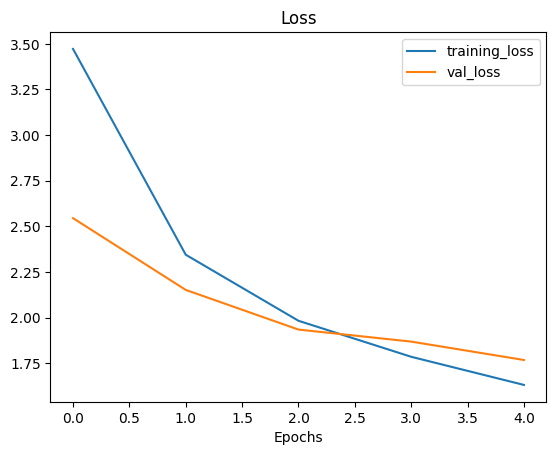

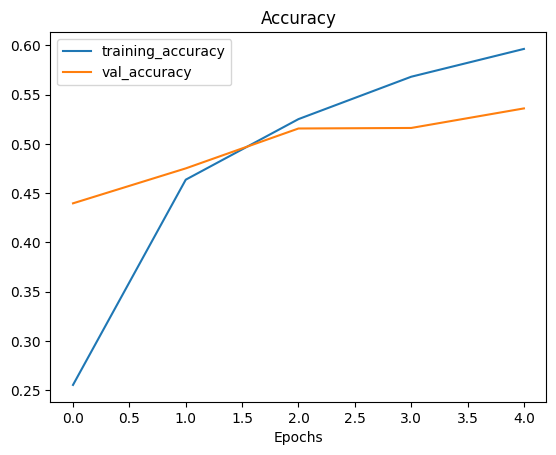

In [13]:
plot_loss_curves(history_all_classes_10_percent)

In [14]:
# Unfreeze all of the layers in the base model
base_model.trainable = True

# Refreeze every layer except for the last 5
for layer in base_model.layers[:-5]:
  layer.trainable = False

In [15]:
# Recompile model with lower learning rate
model.compile(loss='categorical_crossentropy',
              optimizer=tf.keras.optimizers.Adam(1e-4), # 10x lower learning rate than default
              metrics=['accuracy'])

In [16]:
# What layers in the model are trainable?
for layer in model.layers:
  print(layer.name, layer.trainable)

input_layer True
data_augmentation True
efficientnetb0 True
global_average_pooling True
output_layer True


In [17]:
# Check which layers are trainable
for layer_number, layer in enumerate(base_model.layers):
  print(layer_number, layer.name, layer.trainable)

0 input_layer False
1 rescaling False
2 normalization False
3 rescaling_1 False
4 stem_conv_pad False
5 stem_conv False
6 stem_bn False
7 stem_activation False
8 block1a_dwconv False
9 block1a_bn False
10 block1a_activation False
11 block1a_se_squeeze False
12 block1a_se_reshape False
13 block1a_se_reduce False
14 block1a_se_expand False
15 block1a_se_excite False
16 block1a_project_conv False
17 block1a_project_bn False
18 block2a_expand_conv False
19 block2a_expand_bn False
20 block2a_expand_activation False
21 block2a_dwconv_pad False
22 block2a_dwconv False
23 block2a_bn False
24 block2a_activation False
25 block2a_se_squeeze False
26 block2a_se_reshape False
27 block2a_se_reduce False
28 block2a_se_expand False
29 block2a_se_excite False
30 block2a_project_conv False
31 block2a_project_bn False
32 block2b_expand_conv False
33 block2b_expand_bn False
34 block2b_expand_activation False
35 block2b_dwconv False
36 block2b_bn False
37 block2b_activation False
38 block2b_se_squeeze Fals

In [18]:
# Fine-tune for 5 more epochs
fine_tune_epochs = 10 # model has already done 5 epochs, this is the total number of epochs we're after (5+5=10)

history_all_classes_10_percent_fine_tune = model.fit(train_data_all_10_percent,
                                                     epochs=fine_tune_epochs,
                                                     validation_data=test_data,
                                                     validation_steps=int(0.15 * len(test_data)), # validate on 15% of the test data
                                                     initial_epoch=history_all_classes_10_percent.epoch[-1]) # start from previous last epoch

Epoch 5/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 51s 165ms/step - accuracy: 0.6243 - loss: 1.5591 - val_accuracy: 0.5572 - val_loss: 1.7190
Epoch 6/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 37s 154ms/step - accuracy: 0.6496 - loss: 1.4239 - val_accuracy: 0.5689 - val_loss: 1.6657
Epoch 7/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 37s 156ms/step - accuracy: 0.6667 - loss: 1.3278 - val_accuracy: 0.5704 - val_loss: 1.6508
Epoch 8/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 41s 156ms/step - accuracy: 0.6910 - loss: 1.2593 - val_accuracy: 0.5818 - val_loss: 1.6023
Epoch 9/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 39s 149ms/step - accuracy: 0.6932 - loss: 1.2236 - val_accuracy: 0.5877 - val_loss: 1.5789
Epoch 10/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 36s 150ms/step - accuracy: 0.7089 - loss: 1.1576 - val_accuracy: 0.5861 - val_loss: 1.5905


In [19]:
# Evaluate fine-tuned model on the whole test dataset
results_all_classes_10_percent_fine_tune = model.evaluate(test_data)
results_all_classes_10_percent_fine_tune

790/790 ━━━━━━━━━━━━━━━━━━━━ 59s 75ms/step - accuracy: 0.6160 - loss: 1.4293


[1.4293454885482788, 0.6159999966621399]

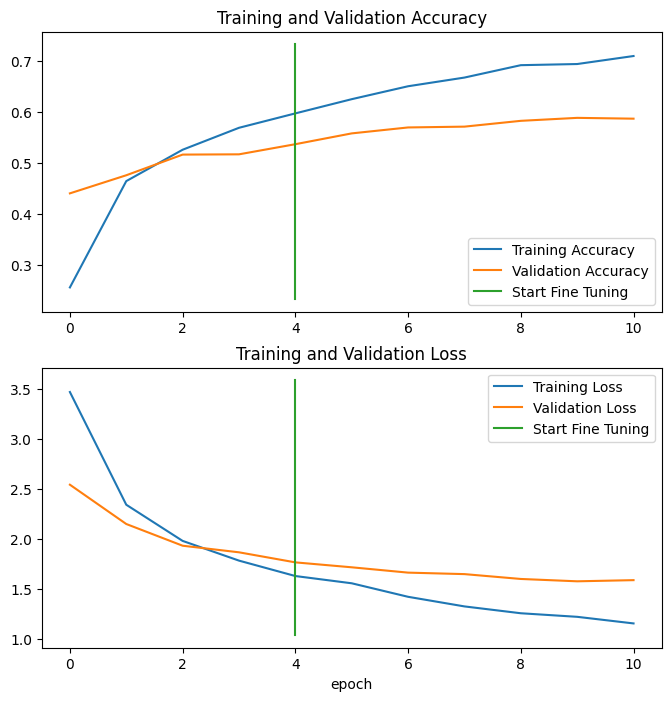

In [20]:
compare_historys(original_history=history_all_classes_10_percent,
                 new_history=history_all_classes_10_percent_fine_tune,
                 initial_epochs=5)

In [21]:
import tensorflow as tf

# Download pre-trained model from Google Storage (like a cooking show, I trained this model earlier, so the results may be different than above)
!wget https://storage.googleapis.com/ztm_tf_course/food_vision/06_101_food_class_10_percent_saved_big_dog_model.zip
saved_model_path = "06_101_food_class_10_percent_saved_big_dog_model.zip"
unzip_data(saved_model_path)

# Note: loading a model will output a lot of 'WARNINGS', these can be ignored: https://www.tensorflow.org/tutorials/keras/save_and_load#save_checkpoints_during_training
# There's also a thread on GitHub trying to fix these warnings: https://github.com/tensorflow/tensorflow/issues/40166
# model = tf.keras.models.load_model("drive/My Drive/tensorflow_course/101_food_class_10_percent_saved_big_dog_model/") # path to drive model
#model = tf.keras.models.load_model(saved_model_path.split(".")[0]) # don't include ".zip" in loaded model path

--2026-06-15 06:33:07--  https://storage.googleapis.com/ztm_tf_course/food_vision/06_101_food_class_10_percent_saved_big_dog_model.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 172.253.154.207, 172.253.153.207, 192.178.156.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|172.253.154.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 46760742 (45M) [application/zip]
Saving to: ‘06_101_food_class_10_percent_saved_big_dog_model.zip’

06_101_food_class_1 100%[===================>]  44.59M  20.8MB/s    in 2.1s    

2026-06-15 06:33:09 (20.8 MB/s) - ‘06_101_food_class_10_percent_saved_big_dog_model.zip’ saved [46760742/46760742]



In [23]:
unzip_data("/content/06_101_food_class_10_percent_saved_big_dog_model.zip")

In [24]:
import tensorflow as tf

# load in saved model using TFSMLayer for Keras 3 compatibility with SavedModel format
# The traceback suggests `keras.layers.TFSMLayer(/content/06_101_food_class_10_percent_saved_big_dog_model, call_endpoint='serving_default')`
# We wrap it in a functional model to maintain compatibility with a 'model' object.
# Note: This loads the model as an inference-only layer.
loaded_sm_layer = tf.keras.layers.TFSMLayer("/content/06_101_food_class_10_percent_saved_big_dog_model", call_endpoint='serving_default')

# To use it as a Keras model, you can wrap it (e.g., if you need to use .predict() directly on it).
# If your original model had a specific input shape, you might need to define it here.
# Assuming the input shape is (None, 224, 224, 3) as per previous cells.
inputs = tf.keras.Input(shape=(224, 224, 3))
outputs = loaded_sm_layer(inputs)
model = tf.keras.Model(inputs=inputs, outputs=outputs)

# You can also load the original model if it was saved in .keras or .h5 format, or if you switch to Keras 2.
# This specific error indicates an incompatibility with Keras 3 and SavedModel via load_model().
# For example, if it was saved as .keras:
# model = tf.keras.models.load_model("/content/06_101_food_class_10_percent_saved_big_dog_model.keras")


In [25]:
# Evalute the loaded model (the one which we downloaded on test data)

# The loaded model needs to be compiled before evaluation.
model.compile(loss="categorical_crossentropy",
              optimizer=tf.keras.optimizers.Adam(),
              metrics=["accuracy"])

results_downloaded_models=model.evaluate(test_data)
results_downloaded_models

790/790 ━━━━━━━━━━━━━━━━━━━━ 65s 66ms/step - accuracy: 0.6078 - loss: 1.7986


[1.7985960245132446, 0.6077623963356018]

Making predictions with trained model


In [26]:
preds_probs=model.predict(test_data,verbose=1)#set verbosity to see how long it left

790/790 ━━━━━━━━━━━━━━━━━━━━ 55s 63ms/step


In [28]:
len(test_data)

790

In [29]:
790*32. # Batch size


25280.0

In [30]:
## how many predictions are there
len(preds_probs)

1

In [31]:
#what is shape of our predictions
# Access the prediction array from the dictionary
preds_probs['dense_8'].shape

(25250, 101)

In [32]:
# let's see how first 10 predictions looks like
preds_probs['dense_8'][:10]

array([[5.9542067e-02, 3.5742310e-06, 4.1377023e-02, ..., 1.4138729e-09,
        8.3531682e-05, 3.0897574e-03],
       [9.6401691e-01, 1.3753327e-09, 8.4780587e-04, ..., 5.4286895e-05,
        7.8362221e-12, 9.8465847e-10],
       [9.5925879e-01, 3.2533990e-05, 1.4867005e-03, ..., 7.1891753e-07,
        5.4397736e-07, 4.0276122e-05],
       ...,
       [4.7313219e-01, 1.2931223e-07, 1.4805566e-03, ..., 5.9750333e-04,
        6.6969289e-05, 2.3469454e-05],
       [4.4571958e-02, 4.7265857e-07, 1.2258447e-01, ..., 6.3498833e-06,
        7.5318758e-06, 3.6779055e-03],
       [7.2438884e-01, 1.9249824e-09, 5.2311032e-05, ..., 1.2291431e-03,
        1.5792788e-09, 9.6395925e-05]], dtype=float32)

In [33]:
# what does the first prediction probability array look like
preds_probs['dense_8'][0],len(preds_probs['dense_8'][0]),sum(preds_probs['dense_8'][0])

(array([5.95420673e-02, 3.57423096e-06, 4.13770229e-02, 1.06607134e-09,
        8.16153456e-09, 8.66406147e-09, 8.09277935e-07, 8.56530335e-07,
        1.98591788e-05, 8.09781170e-07, 3.17281557e-09, 9.86752070e-07,
        2.85323302e-04, 7.80496112e-10, 7.42303091e-04, 3.89166635e-05,
        6.47409706e-06, 2.49775326e-06, 3.78913719e-05, 2.06783213e-07,
        1.55385806e-05, 8.15076135e-07, 2.62307094e-06, 2.00108317e-07,
        8.38278254e-07, 5.42164298e-06, 3.73911666e-06, 1.31506530e-08,
        2.77615152e-03, 2.80519107e-05, 6.85630497e-10, 2.55749437e-05,
        1.66889542e-04, 7.64082853e-10, 4.04529972e-04, 1.31508546e-08,
        1.79574567e-06, 1.44483067e-06, 2.30629928e-02, 8.24676192e-07,
        8.53664801e-07, 1.71387546e-06, 7.05258117e-06, 1.84023357e-08,
        2.85536942e-07, 7.94835796e-06, 2.06818413e-06, 1.85253583e-07,
        3.36197594e-08, 3.15227080e-04, 1.04109595e-05, 8.54493976e-07,
        8.47418368e-01, 1.05554418e-05, 4.40950345e-07, 3.740445

In [35]:
print(f"The predictions probabilities for the sample 0:{len(preds_probs['dense_8'][0])} ")
print(f"what prediction probability sample 0 looks like:\n {preds_probs['dense_8'][0]}")
print(f"The class with the highest probability by the model for sample 0:{preds_probs['dense_8'][0].argmax()}")

The predictions probabilities for the sample 0:101 
what prediction probability sample 0 looks like:
 [5.95420673e-02 3.57423096e-06 4.13770229e-02 1.06607134e-09
 8.16153456e-09 8.66406147e-09 8.09277935e-07 8.56530335e-07
 1.98591788e-05 8.09781170e-07 3.17281557e-09 9.86752070e-07
 2.85323302e-04 7.80496112e-10 7.42303091e-04 3.89166635e-05
 6.47409706e-06 2.49775326e-06 3.78913719e-05 2.06783213e-07
 1.55385806e-05 8.15076135e-07 2.62307094e-06 2.00108317e-07
 8.38278254e-07 5.42164298e-06 3.73911666e-06 1.31506530e-08
 2.77615152e-03 2.80519107e-05 6.85630497e-10 2.55749437e-05
 1.66889542e-04 7.64082853e-10 4.04529972e-04 1.31508546e-08
 1.79574567e-06 1.44483067e-06 2.30629928e-02 8.24676192e-07
 8.53664801e-07 1.71387546e-06 7.05258117e-06 1.84023357e-08
 2.85536942e-07 7.94835796e-06 2.06818413e-06 1.85253583e-07
 3.36197594e-08 3.15227080e-04 1.04109595e-05 8.54493976e-07
 8.47418368e-01 1.05554418e-05 4.40950345e-07 3.74044539e-05
 3.53065188e-05 3.24892426e-05 6.73147224e-0

In [37]:
test_data.class_names[52]

'gyoza'

In [39]:
# get the predict classes of each label
preds_classes = preds_probs['dense_8'].argmax(axis=1)

# how do they look
preds_classes[:10]

array([52,  0,  0, 80, 79, 61, 29,  0, 85,  0])

In [40]:
# how many pred classes do we have
len(preds_classes)

25250

Now we have got prediction array of all of our models predictions, to evaluate them, we need to complate them to the original data set


In [41]:
test_data

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 101), dtype=tf.float32, name=None))>

In [42]:
# toget our test labels we need to unravel our test_data Batchdata set
y_labels=[]
for images, labels in test_data.unbatch():
  y_labels.append(labels.numpy().argmax())

y_labels[:10]# see labels of first 10

[np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0)]

In [ ]:
# Evalating the our model predictions
#one way to check that our model predictions array is in the same order as our test labels array is to find the accuracy score

In [43]:
results_downloaded_models

[1.7985960245132446, 0.6077623963356018]

In [44]:
# let us try scikit learn accuracy score function and see what it comes up with
from sklearn.metrics import accuracy_score
sklearn_accuracy =accuracy_score(y_true=y_labels,
                                 y_pred=preds_classes)
sklearn_accuracy

0.6077623762376237

In [45]:
#Does this metrics come close to our model's evluate results
import numpy as np
np.isclose(results_downloaded_models[1],sklearn_accuracy)

np.True_

Let's get visual : making a confusion matrix
